# Plot light curves of SN Ia with failed fits

Reads ZTFIDs from `failed_ia_fits_spec.txt` and plots each light curve (g and r bands only) using `sncosmo.plot_lc`. No model overlay since the fits failed.

Mirrors the light curve loading conventions in `fit_real_sne_new.py` (`read_ia_lc`).

In [1]:
import numpy as np
import pandas as pd
import sncosmo
import matplotlib.pyplot as plt
from astropy.table import Table

ZP = 25.0
ZPSYS = 'ab'
MIN_POINTS_PER_BAND = 5

def mag_to_bandflux(mag, zp=ZP):
    return 10**(-0.4 * (mag - zp))

def magerr_to_fluxerr(mag, magerr, zp=ZP):
    f = mag_to_bandflux(mag, zp)
    return f * np.log(10) * 0.4 * magerr

In [2]:
# Read the list of failed ZTFIDs (skip the '# ztfid    error' header line)
failed_ztfids = []
with open('failed_ia_fits_spec.txt') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        ztfid = line.split()[0]
        failed_ztfids.append(ztfid)

print(f'Found {len(failed_ztfids)} failed Ia fits to plot')

Found 70 failed Ia fits to plot


In [3]:
def load_failed_lc(ztfid):
    """Load a Ia light curve, keeping only g and r bands.
    Prints a note if i-band data was present or if g/r have <5 points.
    Returns an astropy Table in sncosmo format (or None if empty after filtering).
    """
    filepath = f'ZTFBTS/light-curves/{ztfid}.csv'
    df = pd.read_csv(filepath)

    n_i = df['band'].isin(['i', 'I']).sum()
    if n_i > 0:
        print(f'  note: {ztfid} has {n_i} i-band points (dropped)')
    df = df[~df['band'].isin(['i', 'I'])]

    g_count = (df['band'] == 'g').sum()
    r_count = df['band'].isin(['r', 'R']).sum()
    if g_count < MIN_POINTS_PER_BAND or r_count < MIN_POINTS_PER_BAND:
        print(f'  note: {ztfid} has fewer than {MIN_POINTS_PER_BAND} points per band (g={g_count}, r={r_count})')

    if len(df) == 0:
        return None

    tab = Table.from_pandas(df)
    tab['flux'] = mag_to_bandflux(tab['mag'])
    tab['fluxerr'] = magerr_to_fluxerr(tab['mag'], tab['magerr'])
    tab['zp'] = ZP * np.ones_like(tab['flux'])
    tab['zpsys'] = np.array([ZPSYS] * len(tab), dtype=str)

    band_map = {'g': 'ztfg', 'r': 'ztfr', 'R': 'ztfr'}
    tab['band'] = np.array([band_map.get(b, 'ztf' + b.lower()) for b in tab['band']], dtype=str)

    tab['time'] = tab['time'] - np.min(tab['time'])
    return tab

ZTF19aaqhelq


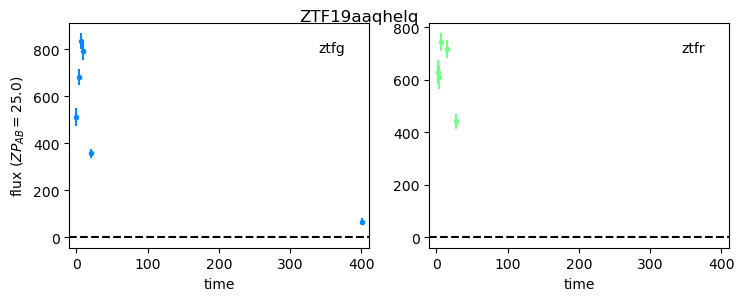

ZTF18aaxsioa


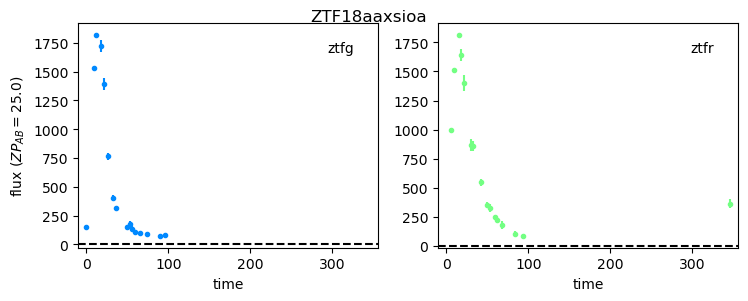

ZTF19adbmgdk


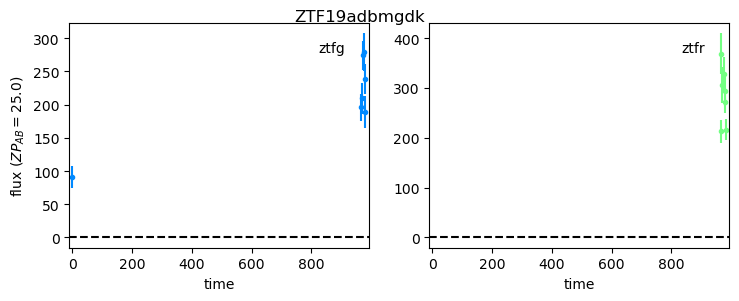

ZTF18aahfbqp


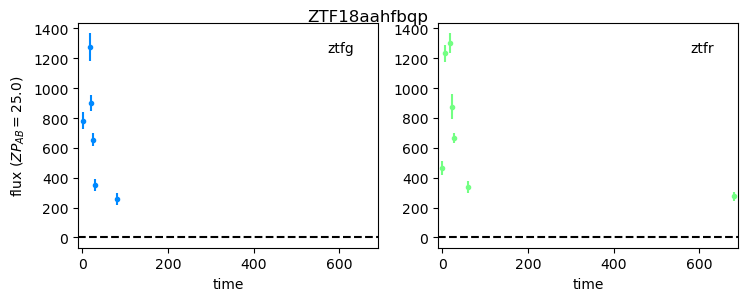

ZTF18aanygjk


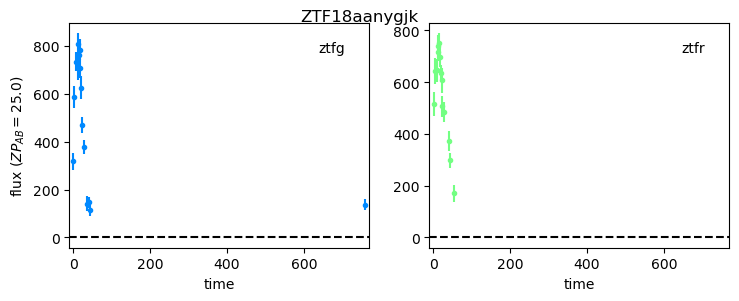

ZTF19aanetjx


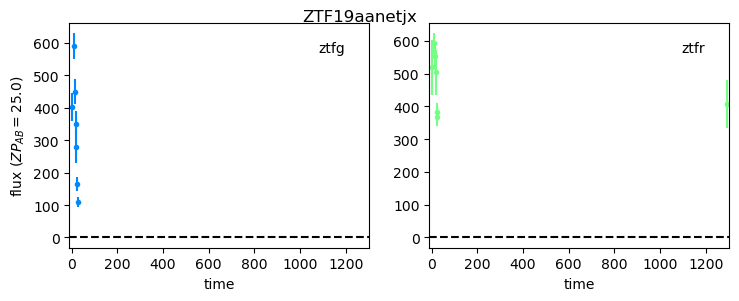

ZTF20abwkqxd


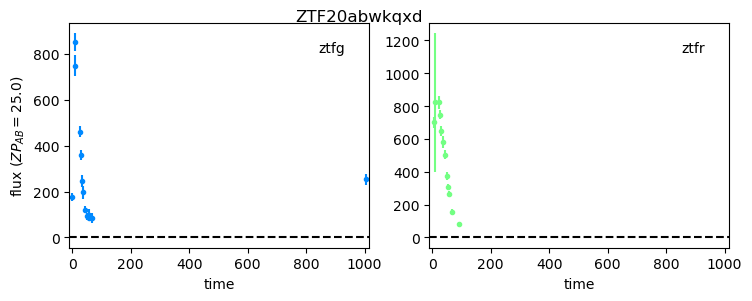

ZTF19aaklqod


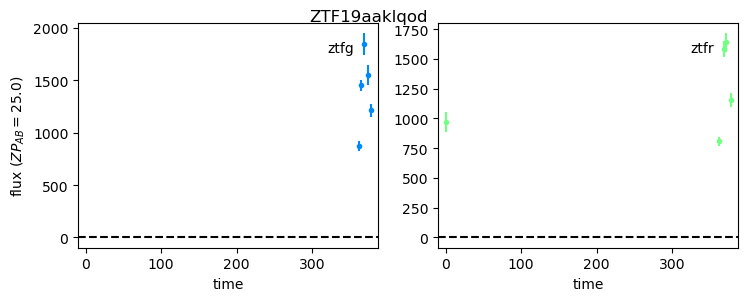

ZTF20abwktfx


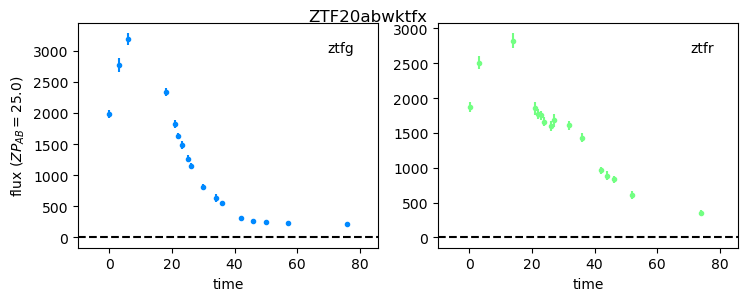

ZTF18acqqyah


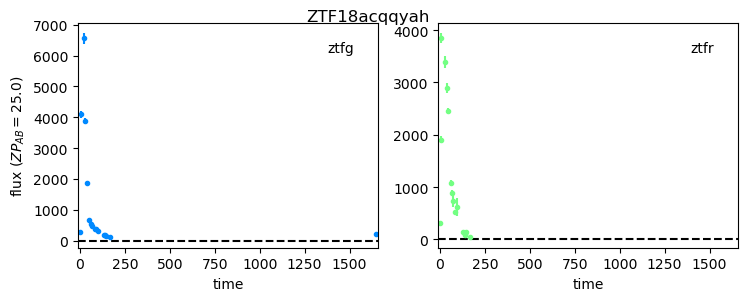

ZTF19aacgslb


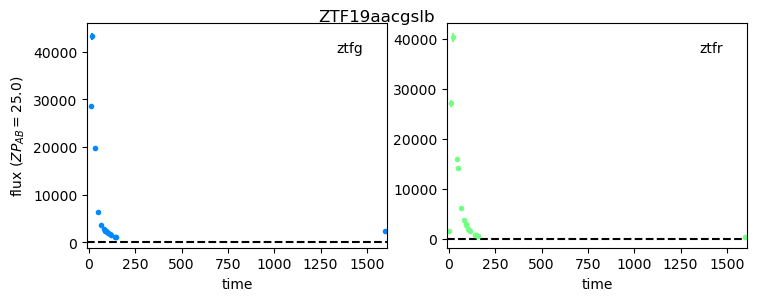

ZTF20abipuee


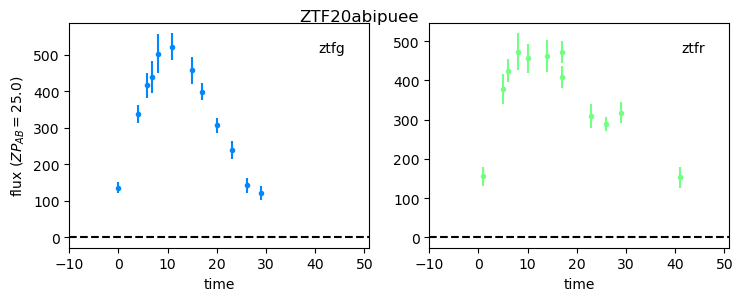

ZTF21abvxguf


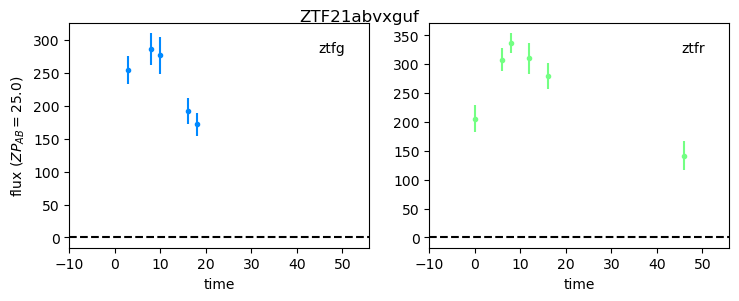

ZTF18acdyypo


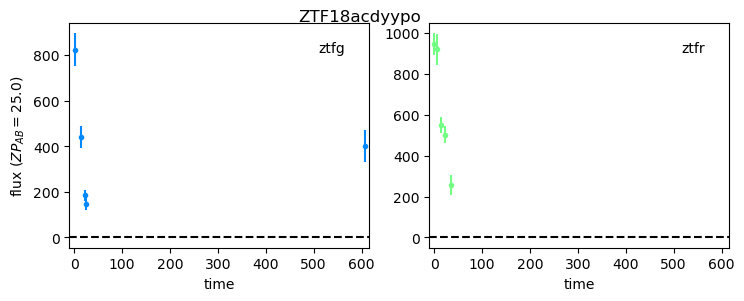

ZTF18aaisqmw


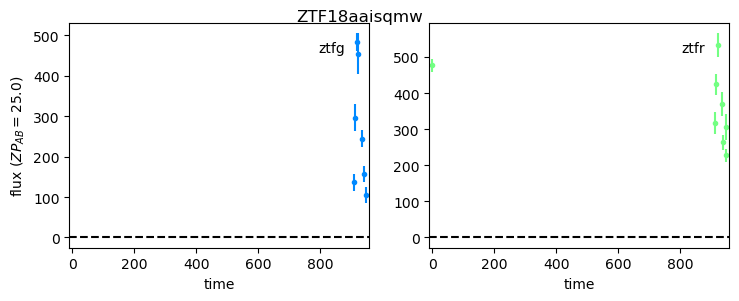

ZTF18acsremz


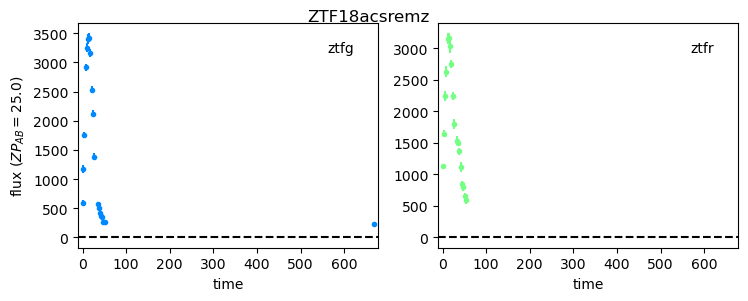

ZTF18aaxmhvk


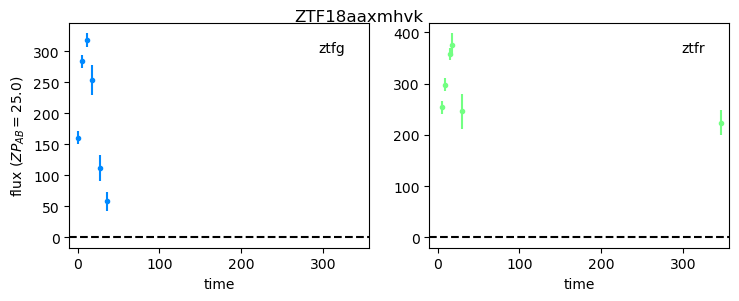

ZTF18aaqskoy


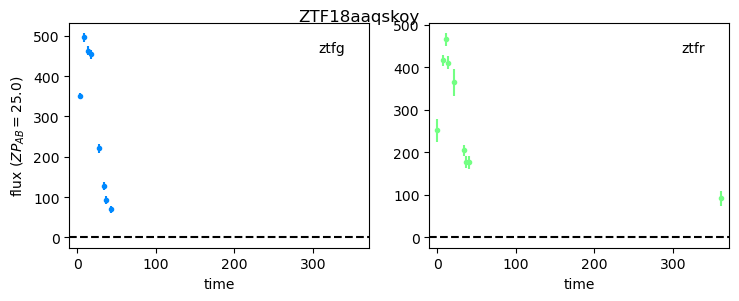

ZTF18aaoxrup


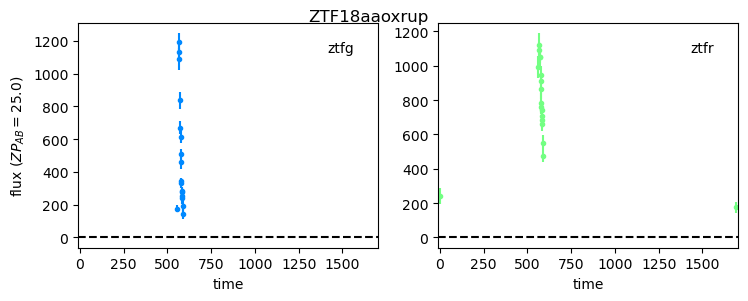

ZTF18accjdgs
  note: ZTF18accjdgs has 1 i-band points (dropped)


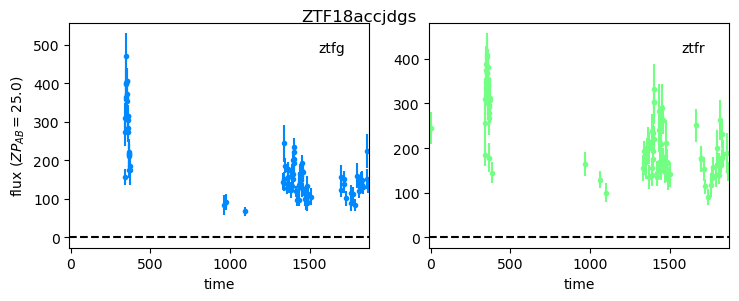

ZTF20abzetdf


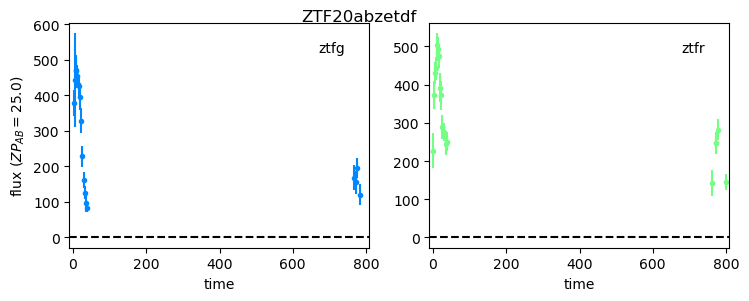

ZTF19aaillan


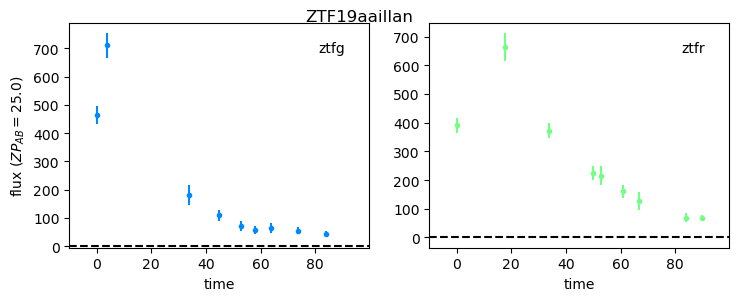

ZTF21aalkknw


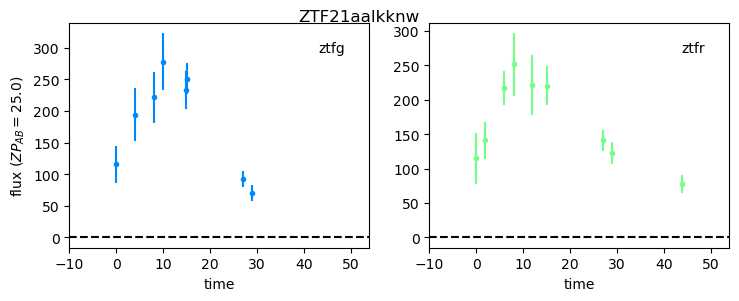

ZTF19abszdld


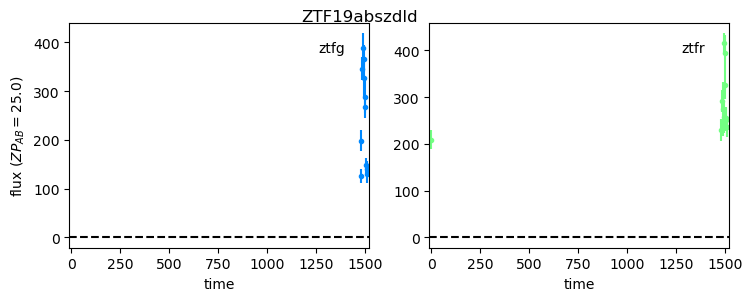

ZTF20acgremo


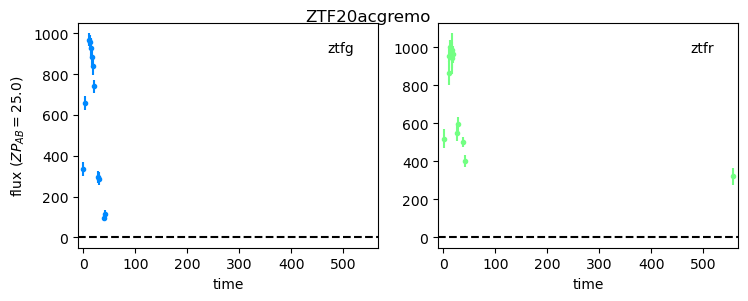

ZTF19abeizmo


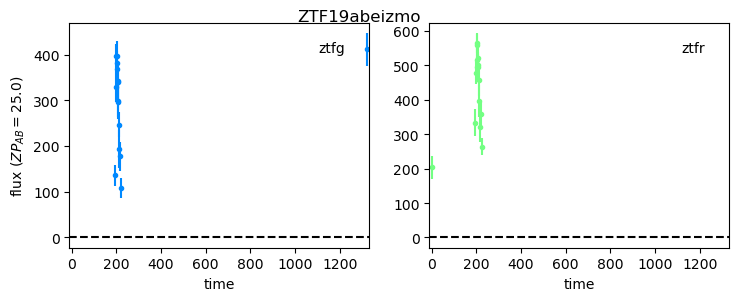

ZTF18abiczpm


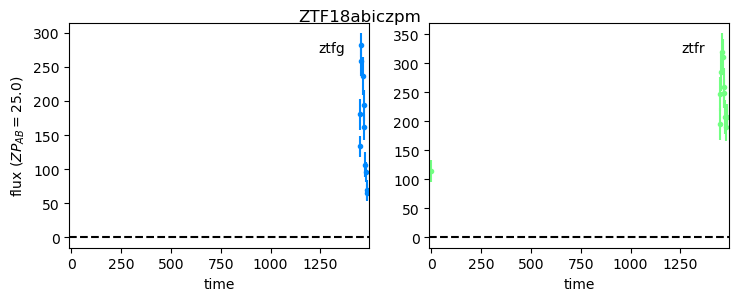

ZTF20acnrphs


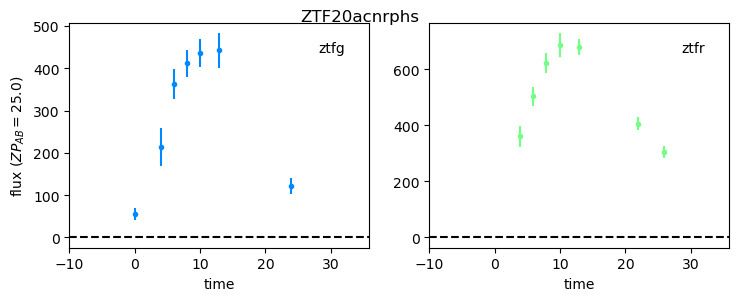

ZTF20aaghoqz


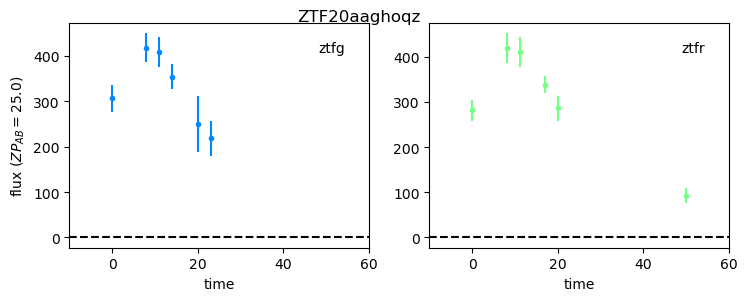

ZTF19abaejto


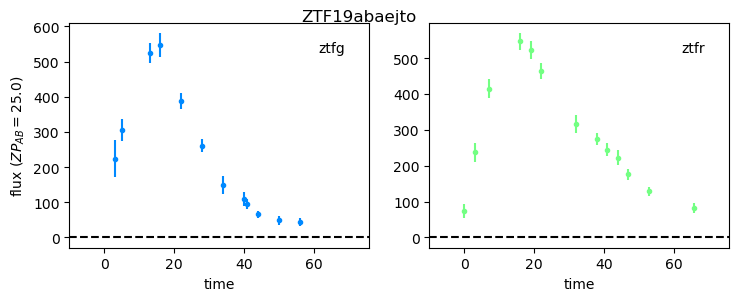

ZTF18abxhaop


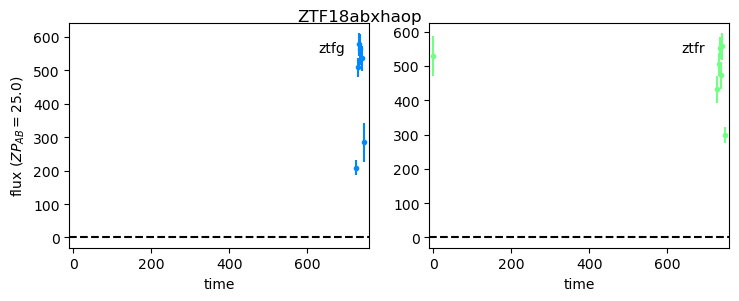

ZTF21aanswls


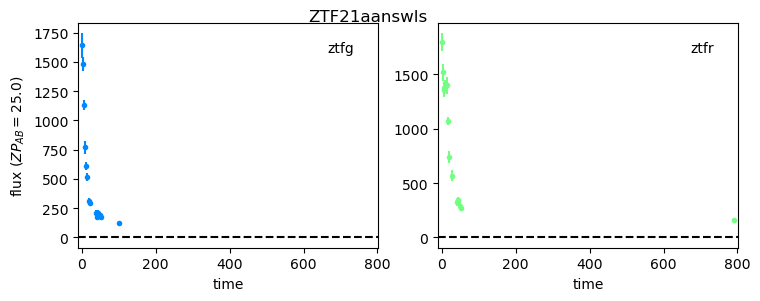

ZTF20acumrio


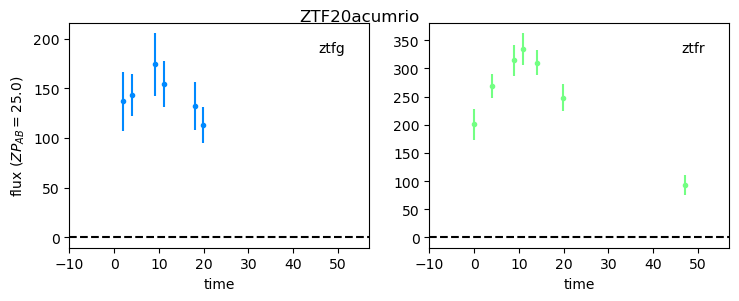

ZTF20aaetvkh


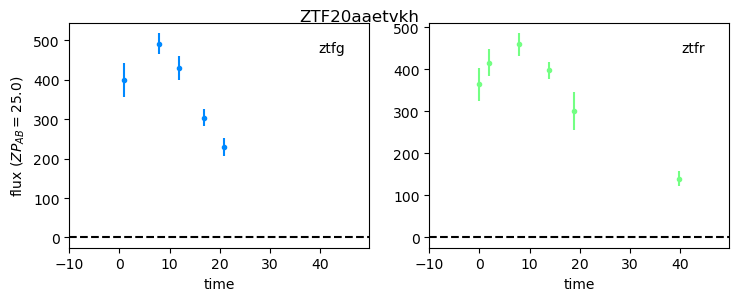

ZTF20acpbbqf


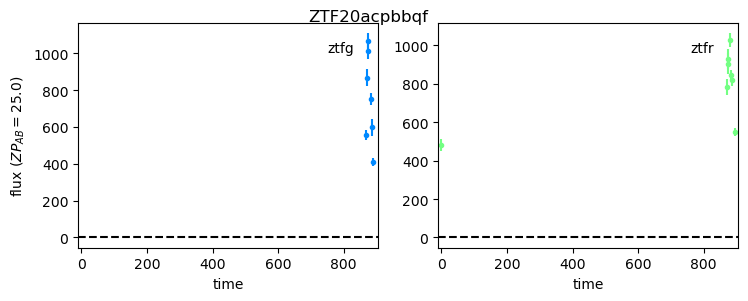

ZTF19acytidb


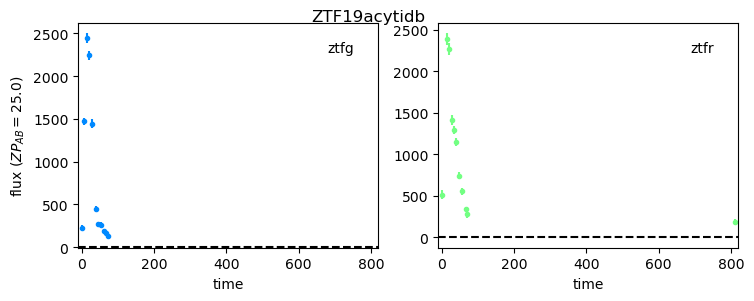

ZTF19aambfxc


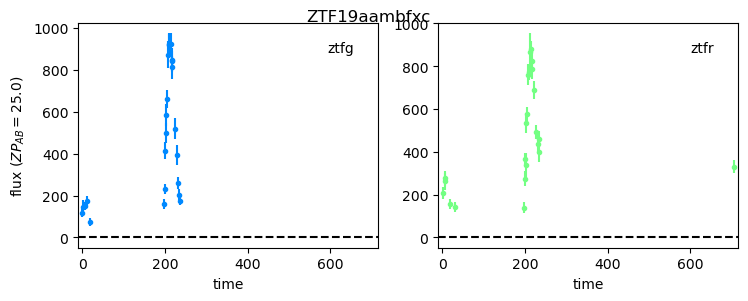

ZTF18acskxpn


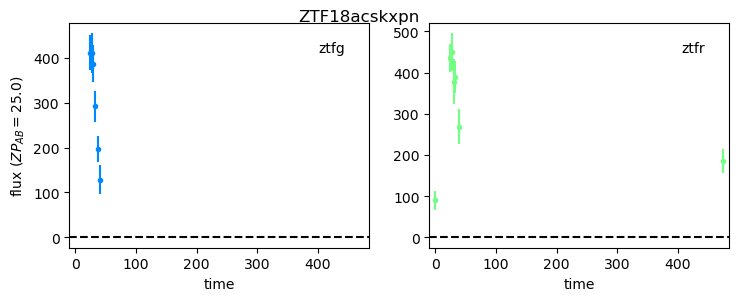

ZTF20aazymxi


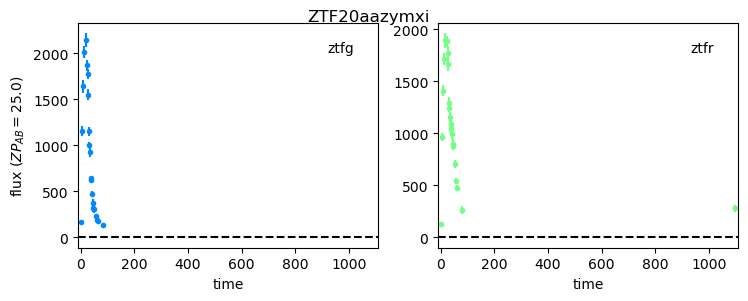

ZTF21abgxudc


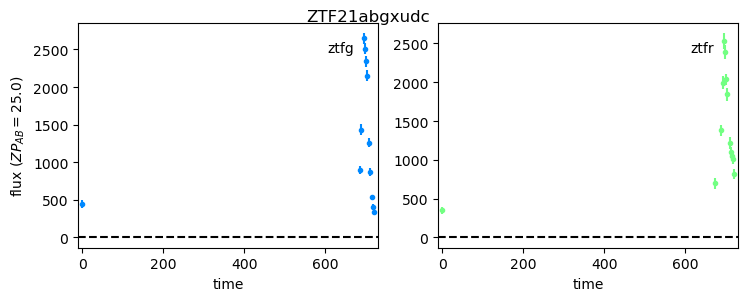

ZTF18abaxlpi


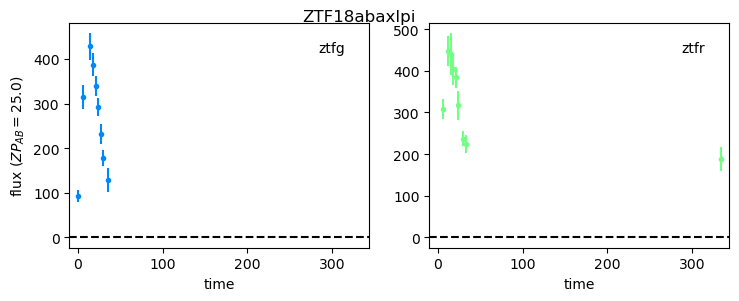

ZTF19abgafkt


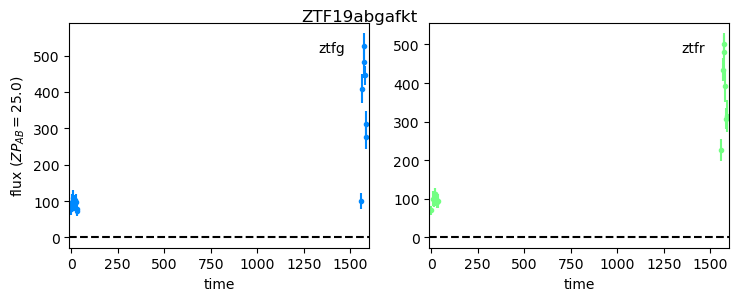

ZTF21aamwlzd


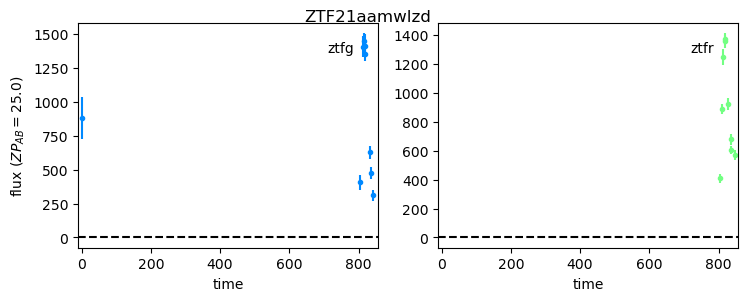

ZTF18aayyqia


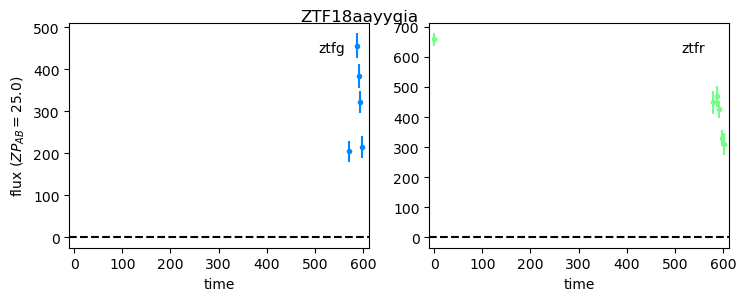

ZTF20aavpnlv


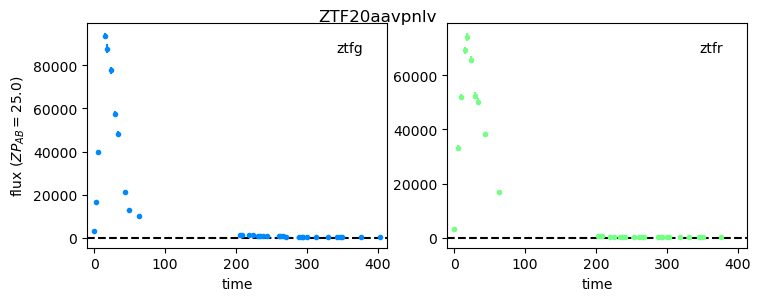

ZTF19ablekwo


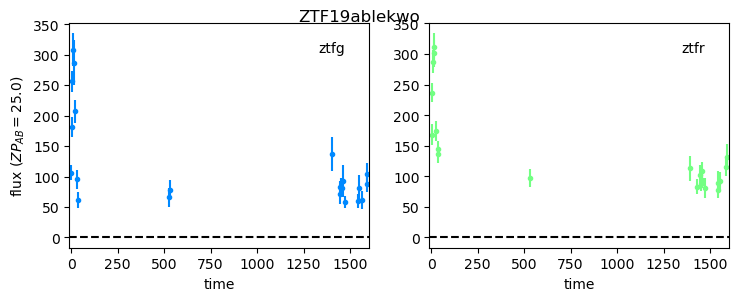

ZTF18abcdzyc


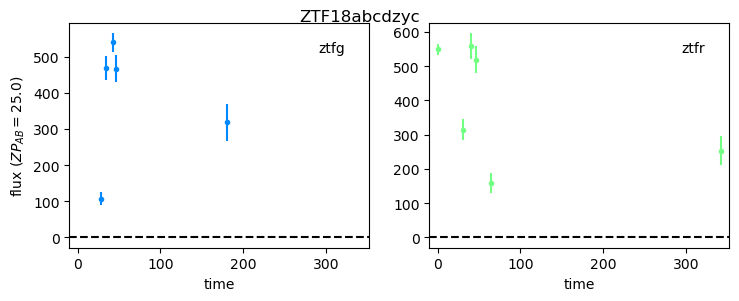

ZTF18aaiykoz


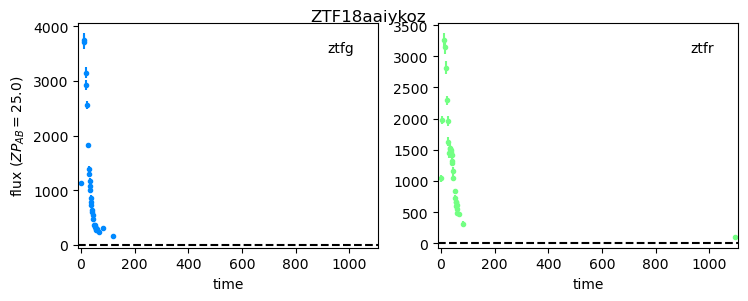

ZTF21abdpios


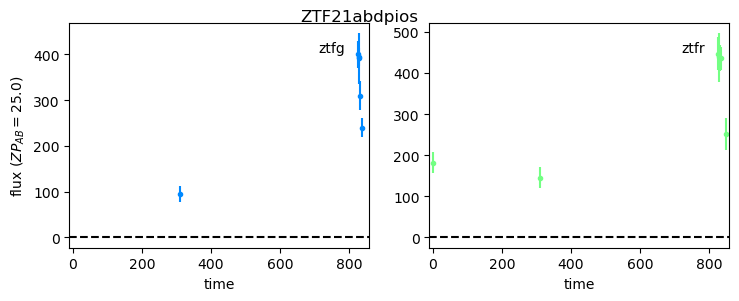

ZTF19aaarhtg


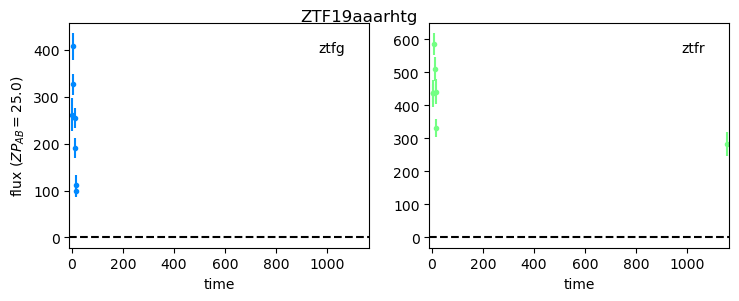

ZTF18aawlxls


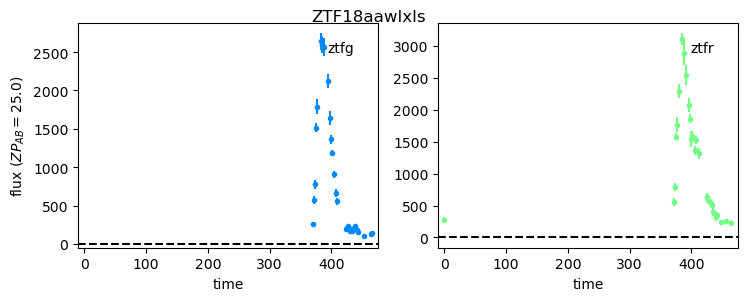

ZTF18aawmeiw


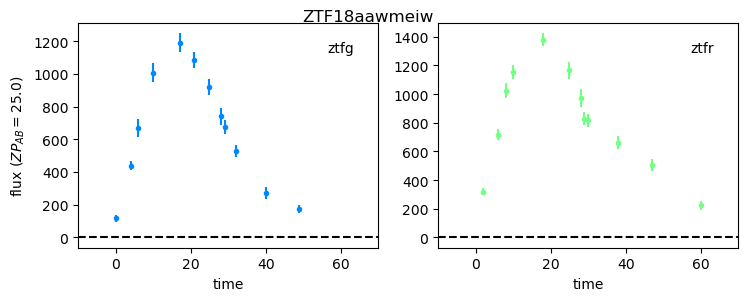

ZTF19aatlmbo


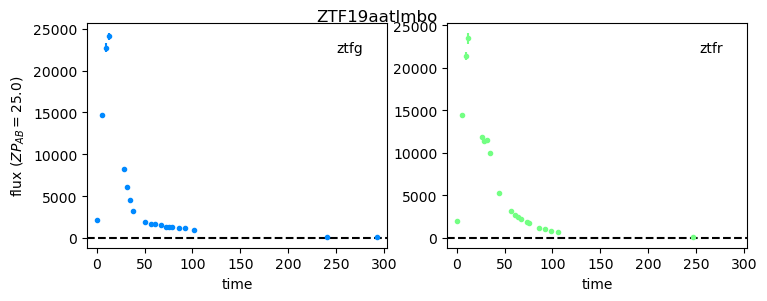

ZTF20acrudzk


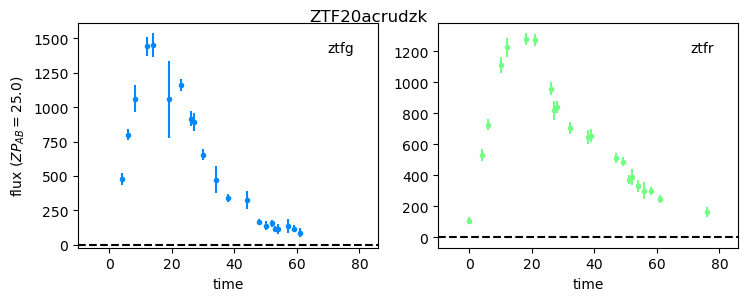

ZTF19acmbhvv


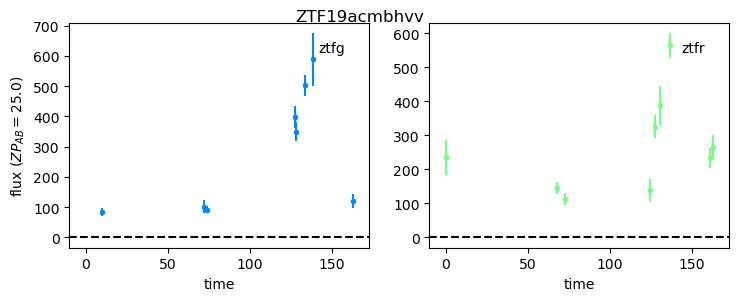

ZTF21abnfgff


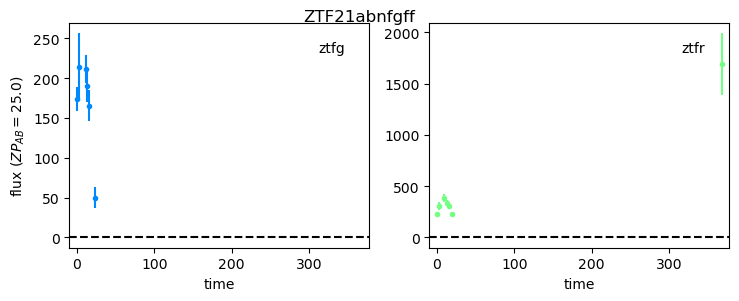

ZTF18aaxgwpl


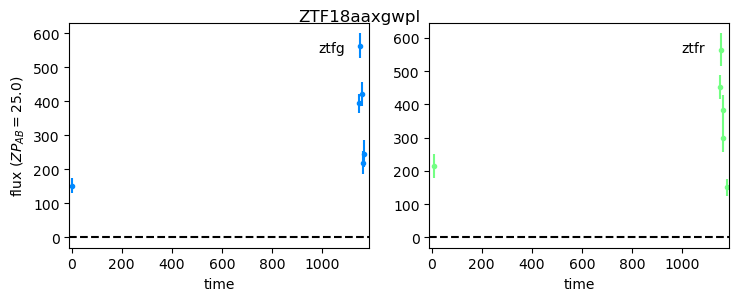

ZTF21abcmvci


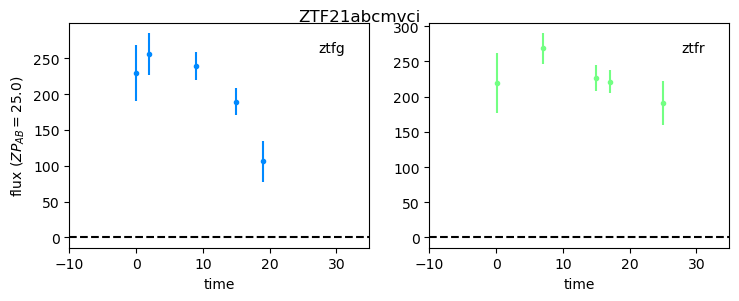

ZTF18aaklpdo


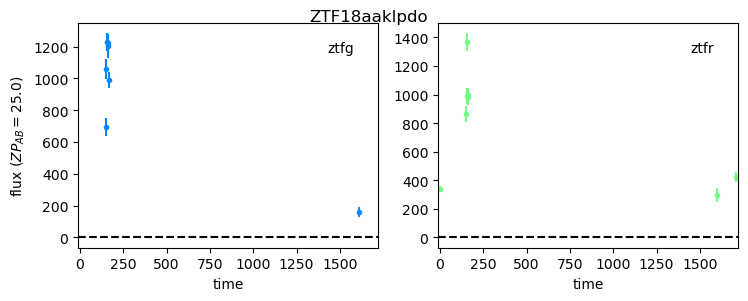

ZTF21aajfpwk


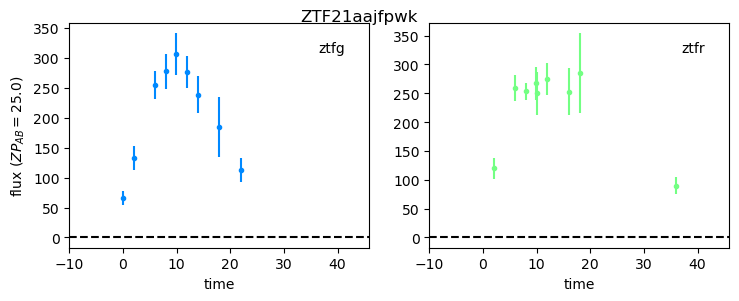

ZTF19aalveag


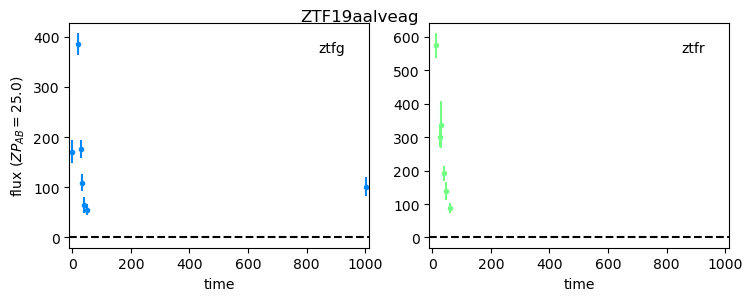

ZTF23abjzkqu


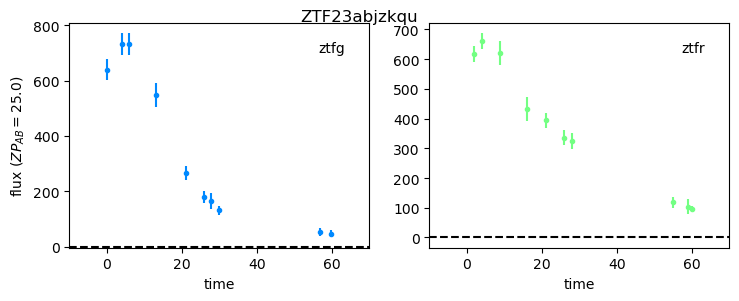

ZTF20acpylns


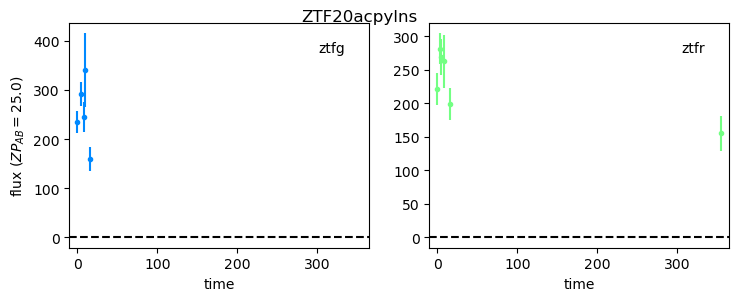

ZTF20aaxahpk


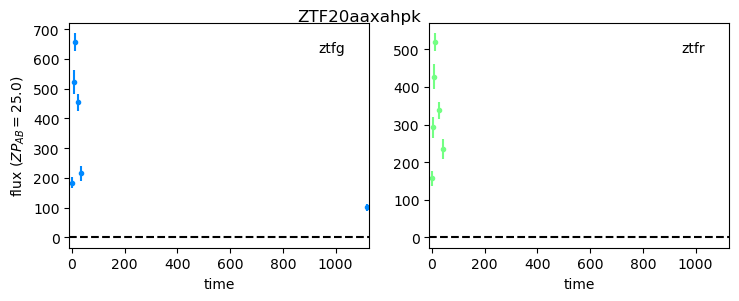

ZTF20acoyvdg


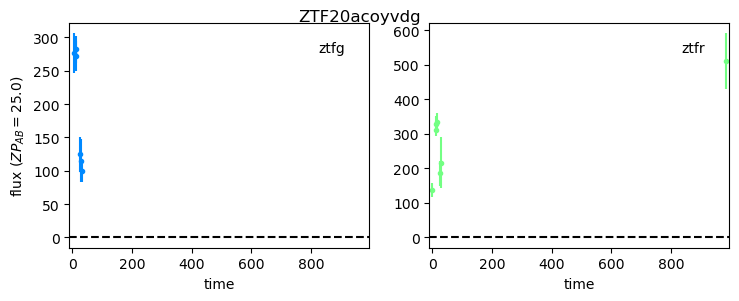

ZTF20abmarcv


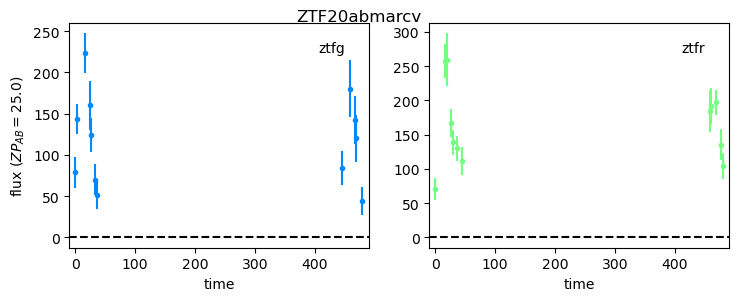

ZTF20achlced


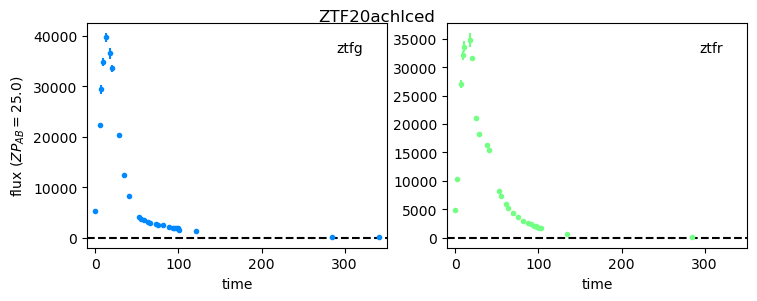

ZTF21abqfttg


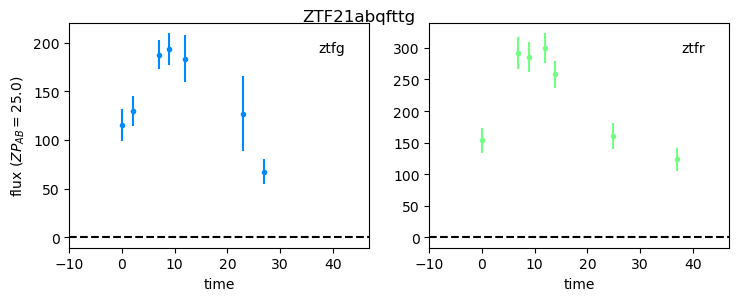

ZTF18aajpjdi


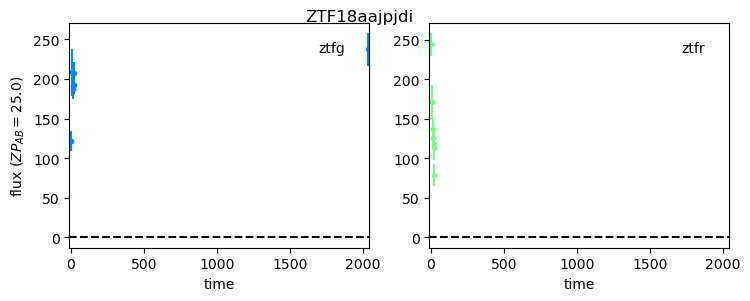

ZTF18abzzkyg


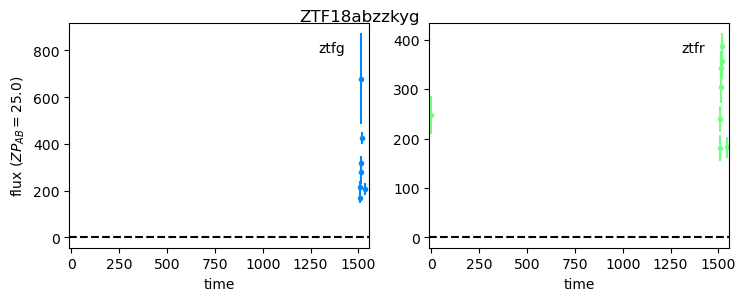

In [4]:
for ztfid in failed_ztfids:
    print(ztfid)
    try:
        lc = load_failed_lc(ztfid)
    except FileNotFoundError:
        print(f'  light curve file not found for {ztfid}, skipping')
        continue
    if lc is None or len(lc) == 0:
        print(f'  no g/r data for {ztfid}, skipping plot')
        continue
    fig = sncosmo.plot_lc(lc)
    fig.suptitle(ztfid)
    plt.show()